In [1]:
import sys
import os

import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from tqdm import tqdm

sys.path.insert(0, "../code")
import measure_signal as ms
import dataset_utils as du
from Pipeline1_SNR_datasets import execute_specsnr_algorithm

plt.style.use("/home/2649/repos/foxstyle/custom.mplstyle")

In [2]:
dir_project = "/lustre/lrspec/users/2649/SNRvsR"
dir_data = os.path.join(dir_project, "datasets")

In [3]:
folder_snr_arr = [
    # "SNR000.5",
    # "SNR000.6",
    # "SNR000.7",
    # "SNR000.8",
    # "SNR000.9",
    # "SNR001",
    # "SNR001.25",
    # "SNR001.5",
    # "SNR001.75",
    # "SNR002",
    "SNR002.5",
    # "SNR005",
    # "SNR020",
    "SNR025",
    # "SNR050",
    # "SNR100",
][::-1]
# folder_R_arr = [
#     # "R010",
#     # "R015",
#     # "R020",
#     "R025",
#     # "R030",
#     # "R035",
#     # "R040",
#     # "R045",
#     "R050",
#     "R100",
#     # "R200",
#     # "R300",
#     # "R400",
#     # "R500",
# ][::-1]

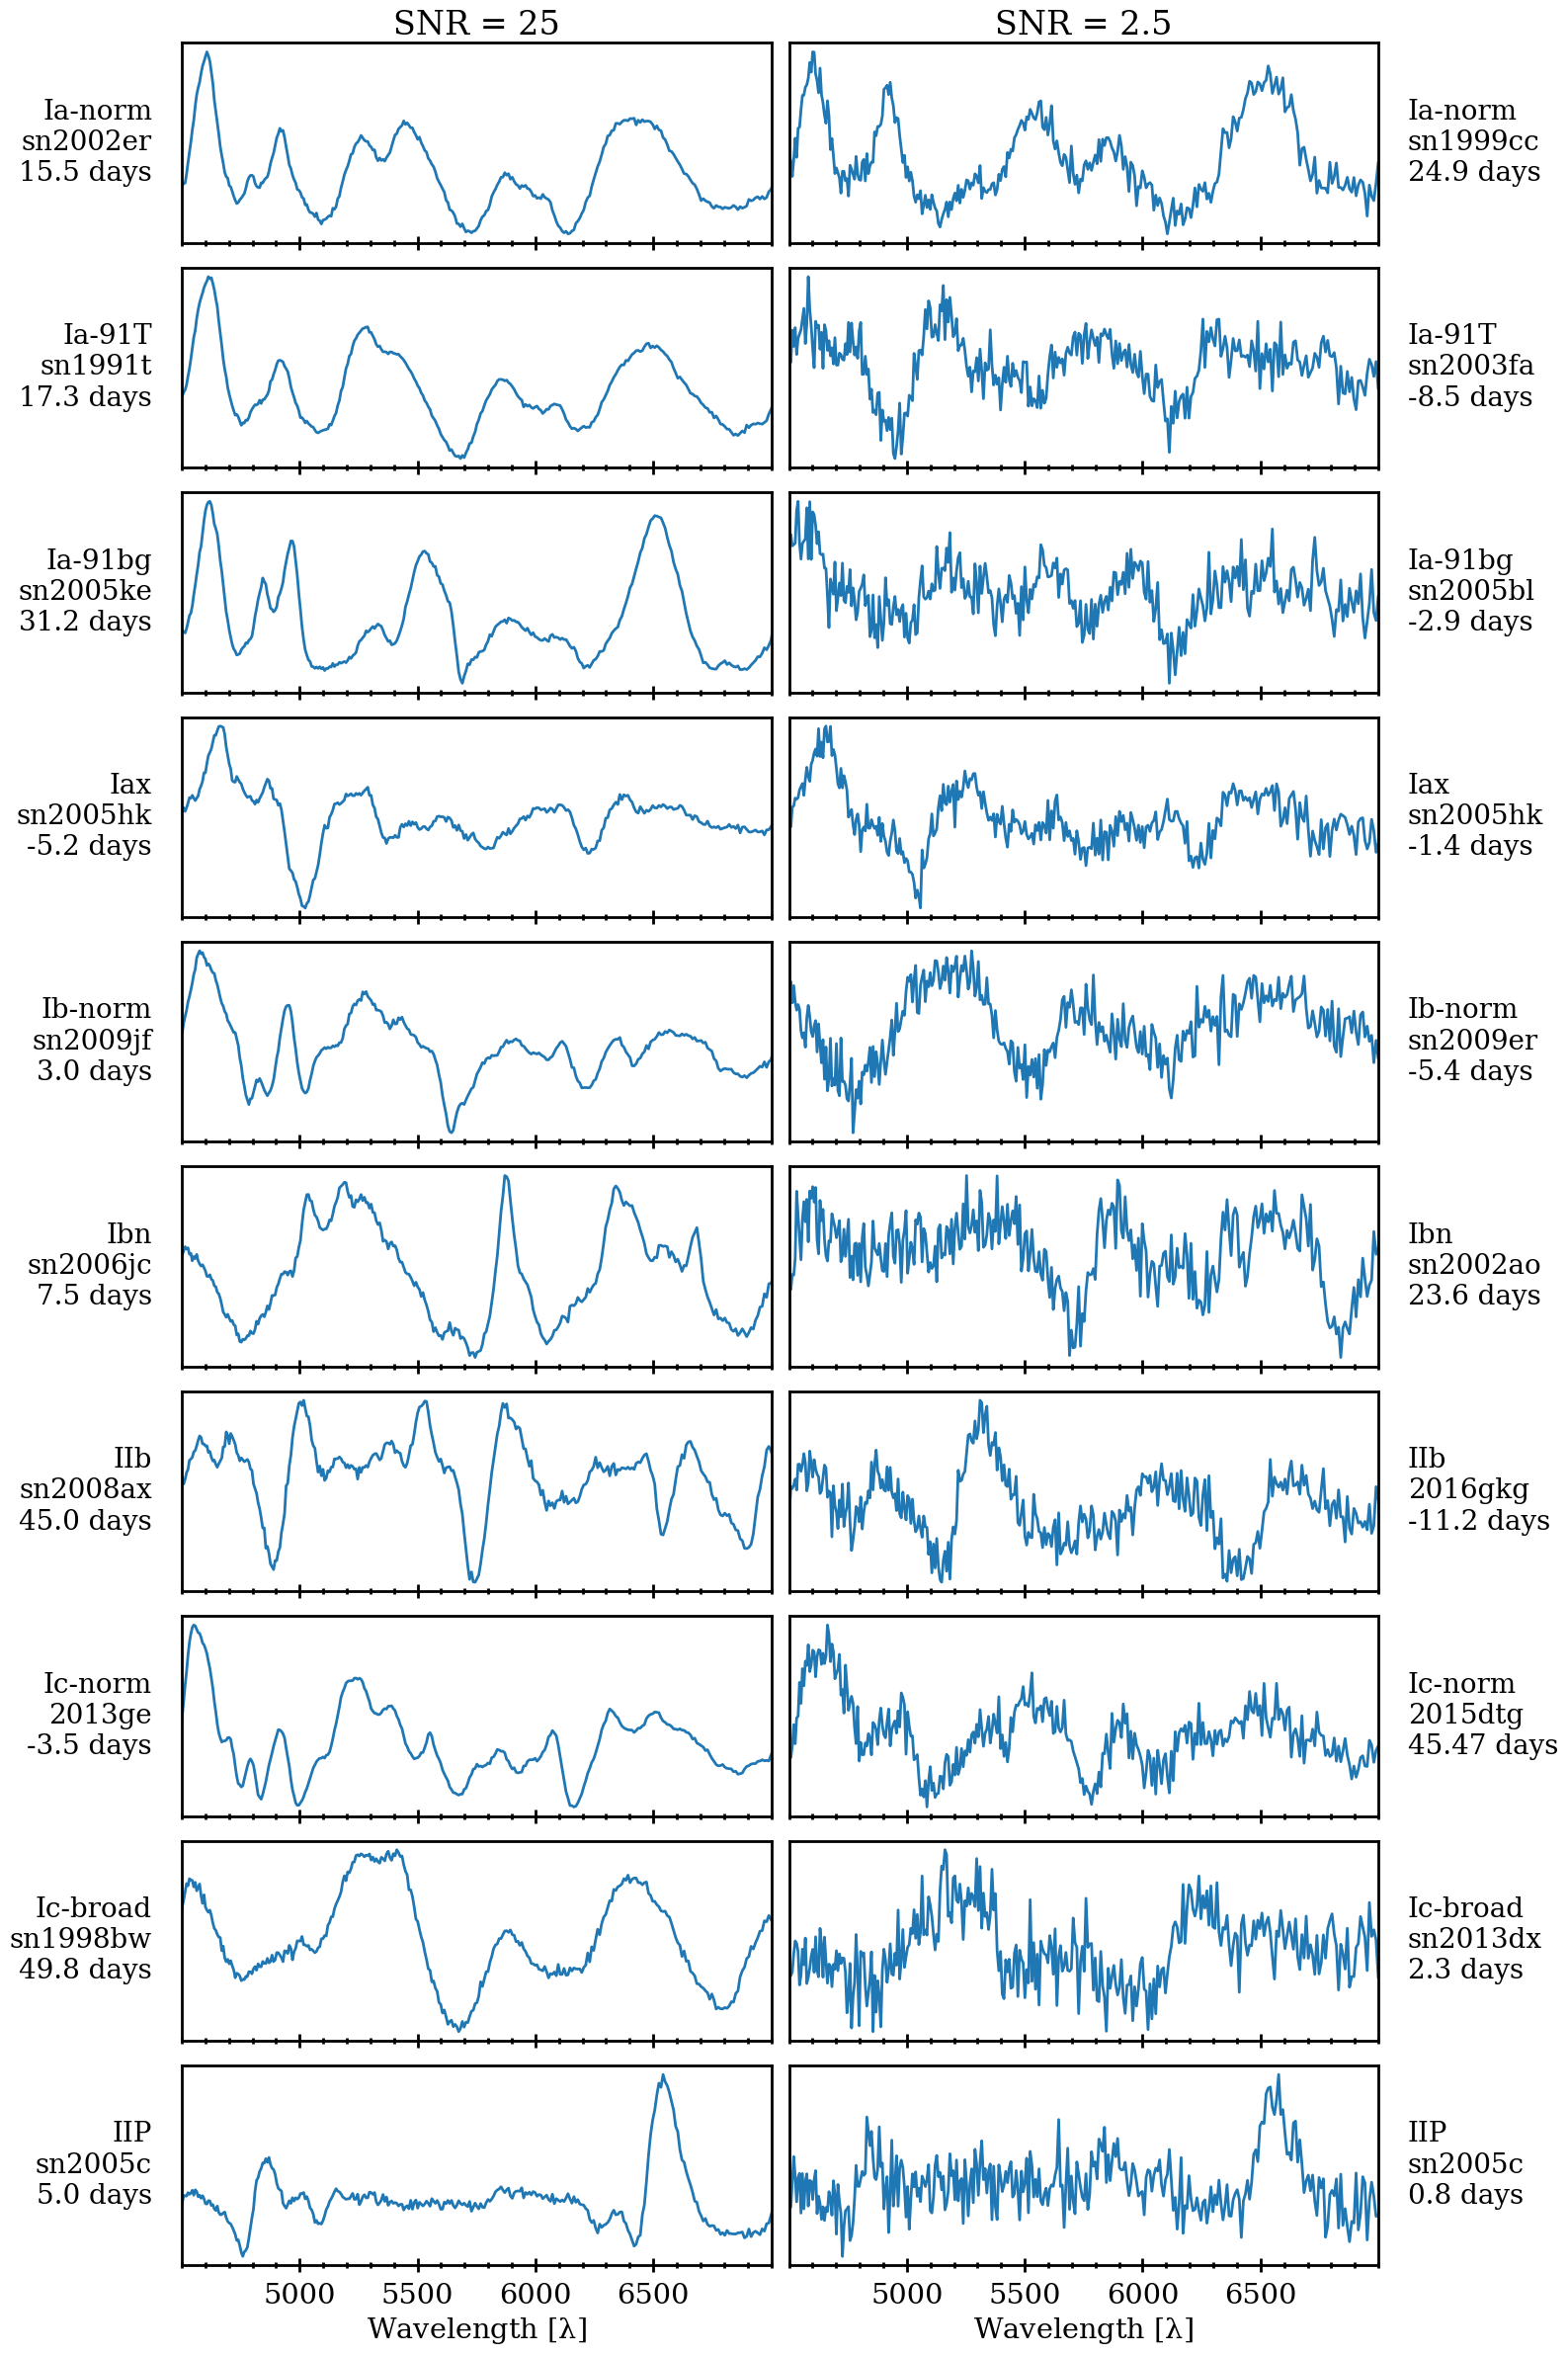

In [4]:
fig, axes = plt.subplots(nrows=10, ncols=2, sharex=True, figsize=(16, 24))


for i, folder_snr in enumerate(folder_snr_arr):
    SNR = float(folder_snr.split("SNR")[-1])
    if int(SNR) == SNR:
        SNR = int(SNR)

    file_dataset = os.path.join(dir_data, folder_snr, "dataset_SNRclipped.parquet")
    df = pd.read_parquet(file_dataset)
    wvl, spectra, df_meta = du.unpack_dataset(df)
    df_meta["Relative SNR"] = np.abs(df_meta["SNR"] - SNR)

    subtypes = df_meta["SN Subtype"].unique()
    for j, subtype in enumerate(subtypes):
        mask = df_meta["SN Subtype"] == subtype
        closest_SNR = np.min(df_meta.loc[mask, "Relative SNR"])

        mask &= df_meta["Relative SNR"] == closest_SNR
        assert mask.sum() == 1
        spec_ind = df_meta.loc[mask].index[0]

        axes[j, i].plot(wvl, spectra[spec_ind])
        axes[j, i].tick_params(axis="both", which="both", direction="inout", bottom=True, top=False, left=False, right=False)
        axes[j, i].set_yticklabels([])
        axes[j, i].set_xticks([5000, 5500, 6000, 6500])
    
        if i == 0:
            xpos = -0.05
            ha = "right"
        else:
            ha = "left"
            xpos = 1.05

        name = df_meta.loc[mask, 'SN Name'].item()
        if name[0] == "u":
            name = name[1:]

        subtype_confirm = df_meta.loc[mask, 'SN Subtype'].item()
        phase = df_meta.loc[mask, 'Spectrum Phase'].item()

        axes[j, i].text(
            xpos,
            0.5,
            f"{subtype_confirm}\n{name}\n{phase} days",
            ha=ha, va="center",
            size=20,
            transform=axes[j, i].transAxes)

    axes[0, i].set_title(f"SNR = {SNR}", size=24)
    axes[9, i].set_xlabel("Wavelength [$\lambda$]")
    
axes[0, 0].set_xlim((4500, 7000))


fig.tight_layout()
fig.savefig("spectrum_per_class_SNR.pdf")
fig.savefig("spectrum_per_class_SNR.png")
fig.show()